# Control command (u) and state estimate (x_hat) perturbation plots

In [148]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from model import lqg_model

%matplotlib inline

## Initialize LQG Model with Parameters

In [149]:
# define horizon (number of time steps)
horizon = 2000

# target position
T_p = 100

# target velocity
T_v = 0

# instantiate LQG model with specified horizon and target state
lqg_baseline = lqg_model.LQG(horizon, target=[T_p, # position 100
                                                            T_v]) # velovity 0


# initial state: position, velocity
x0 = np.matrix([[0],
                [0]])

# set initial state estimate
initial_xhat = np.array([[0.0],
                         [0.0]])


# define system dynamics matrices
dt = 0.01  # time step in seconds (10 ms per step), 5 sec in total

# A: state transition matrix for a 1D system (position and velocity)
A = np.matrix([[1, dt],
               [0, 1]])

# B: control input matrix (acceleration)
B = np.matrix([[0],
               [dt]])

# C: observation matrix (position and velocity)
C = np.matrix([[1, 0], # obs position
               [0, 1]]) # and obs velocity

# define cost matrices
# Q: state cost (penalize deviation from target at final time)
# high cost on position error, low cost on velocity error
# R: control cost (penalize control effort)
Q = np.matrix([[500, 0],
               [0, 1]])
R = np.matrix([[0.0001]])
 
# V: process noise covariance (std)
V = np.matrix([[0.001, 0],
               [0, 0.001]])

# W: observation noise covariance (std)
W = np.matrix([[1.5, 0],
               [0, 1.5]])

# X0: initial state covariance 
X0 = np.matrix([[0.1, 0],
                [0, 0.1]])

# define model parameters
lqg_baseline.define('A', A)
lqg_baseline.define('B', B)
lqg_baseline.define('C', C)
lqg_baseline.define('Q', Q)
lqg_baseline.define('R', R)
lqg_baseline.define('V', V)
lqg_baseline.define('W', W)
lqg_baseline.define('X', X0)

print("LQG model:")
print(f"\tHorizon: {horizon} time steps")
print(f"\tTime step: {dt}s")

LQG model:
	Horizon: 2000 time steps
	Time step: 0.01s


## Baseline Simulation (No Perturbation)

In [150]:
np.random.seed(42)

# random noise 
v_noise = [np.random.randn(2, 1) for _ in range(horizon)]  # process noise
w_noise = [np.random.randn(2, 1) for _ in range(horizon)]  # measurement noise

# initialize true state and state estimate lists
x_baseline_list = [x0.copy()]  # true state
xhat_baseline_list = [x0.copy()]  # state estimate (starts at x0)
u_baseline_list = []

# define target state as a column vector for position and velocity
target = np.matrix([[T_p], [T_v]])

# control gains
lqg_baseline.kalman()  # Kalman gains (L)
lqg_baseline.control()  # control gains (K)

# simulate with control
for t in range(horizon - 1):
    # controller: compute control based on state estiamte
    u_t = lqg_baseline.var['K'][t] * (xhat_baseline_list[t] - target)
    u_baseline_list.append(u_t)
    
    # true state update w process noise
    x_next = A * x_baseline_list[t] + B * u_t + V * np.matrix(v_noise[t])
    x_baseline_list.append(x_next)
    
    # observation with observation nosie
    y = C * x_next + W * np.matrix(w_noise[t+1])
    
    # Kalman filter update
    # prediction step
    xhat_pred = A * xhat_baseline_list[t] + B * u_t
    
    # upate step
    y_tilde = y - C * xhat_pred
    # correction - update to state intermal model
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde
    xhat_baseline_list.append(xhat_next)

# add final control
u_final = lqg_baseline.var['K'][horizon-1] * (xhat_baseline_list[-1] - target)
u_baseline_list.append(u_final)

# convert to arrays
x_baseline = np.array([x_baseline_list[t][0, 0] for t in range(horizon)])
v_baseline = np.array([x_baseline_list[t][1, 0] for t in range(horizon)])
xhat_baseline = np.array([xhat_baseline_list[t][0, 0] for t in range(horizon)])
vhat_baseline = np.array([xhat_baseline_list[t][1, 0] for t in range(horizon)])
u_baseline = np.array([u_baseline_list[t][0, 0] for t in range(horizon)])

# store baseline data in a dictionary 
baseline_data = {
    'x': x_baseline_list,
    'kf': {'x1': xhat_baseline_list},
    'u': u_baseline_list,
    'control': True,
    'noise': {
        'v': [np.matrix(v_noise[t]) for t in range(horizon)],
        'w': [np.matrix(w_noise[t]) for t in range(horizon)]
    },
    'target': target
}

# summary
error_baseline = x_baseline - xhat_baseline
print("baseline simulation summary:")
print(f"\tinitial: x[0]={x_baseline[0]:.6f}, xhat[0]={xhat_baseline[0]:.6f}")
print(f"\tfinal: x[-1]={x_baseline[-1]:.4f}, xhat[-1]={xhat_baseline[-1]:.4f}")
print(f"\tmean |error|: {np.mean(np.abs(error_baseline)):.4f}")
print(f"\tmax |error|: {np.max(np.abs(error_baseline)):.4f}")
print(f"\tstd |error|: {np.std(error_baseline):.4f}")

baseline simulation summary:
	initial: x[0]=0.000000, xhat[0]=0.000000
	final: x[-1]=99.9717, xhat[-1]=100.0214
	mean |error|: 0.1081
	max |error|: 0.2595
	std |error|: 0.0652


## Perturb u
- inject a pulse (decrease in acceleration) to u
- do not expect x and xhat to diverge during trajectory

In [151]:
np.random.seed(42)
# perturbation timing
perturbation_start = 200
perturbation_end = 250

# per-dimension control perturbation magnitude
# 1D model: single acceleration axis (ax)
u_pert_magnitude = -25 # ax perturbation

# same noise as baseline for comparison
v_noise = baseline_data['noise']['v']
w_noise = baseline_data['noise']['w']
target = np.matrix([[T_p], [T_v]])

# copy baseline data up to perturbation point
x_u_pert_list = [baseline_data['x'][t].copy() for t in range(perturbation_start + 1)]
xhat_u_pert_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
u_u_pert_list = [baseline_data['u'][t].copy() for t in range(perturbation_start)]

for t in range(perturbation_start, horizon - 1):
    # LQG controller: track fixed target throughout
    u_intended = lqg_baseline.var['K'][t] * (xhat_u_pert_list[t] - target)

    # actual control: includes perturbation pulse during window
    u_actual = u_intended.copy()
    if perturbation_start <= t < perturbation_end:
        u_actual = u_actual + u_pert_magnitude
    u_u_pert_list.append(u_actual)

    # true state dynamics
    x_next = A * x_u_pert_list[t] + B * u_actual + V * v_noise[t]
    x_u_pert_list.append(x_next)

    # observation from true state
    y = C * x_next + W * w_noise[t + 1]

    # Kalman filter: efference copy uses u_actual
    xhat_pred = A * xhat_u_pert_list[t] + B * u_actual
    y_tilde = y - C * xhat_pred
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde
    xhat_u_pert_list.append(xhat_next)

# final control: fixed target
u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_u_pert_list[-1] - target)
u_u_pert_list.append(u_final)

# convert to arrays
x_u_pert    = np.array([x_u_pert_list[t][0, 0]    for t in range(horizon)])
v_u_pert    = np.array([x_u_pert_list[t][1, 0]    for t in range(horizon)])
xhat_u_pert = np.array([xhat_u_pert_list[t][0, 0] for t in range(horizon)])
vhat_u_pert = np.array([xhat_u_pert_list[t][1, 0] for t in range(horizon)])
u_pert_array = np.array([u_u_pert_list[t][0, 0]   for t in range(horizon)])

# recovery metric: deviation from baseline trajectory
deviation_u = np.abs(x_u_pert - x_baseline)
tol = 1.0
recovery_steps = next((t - perturbation_end for t in range(perturbation_end, horizon)
                        if deviation_u[t] < tol), horizon - perturbation_end)

u_pert_data = {
    'x': x_u_pert_list,
    'kf': {'x1': xhat_u_pert_list},
    'u': u_u_pert_list,
    'control': True,
    'noise': baseline_data['noise'],
    'target': target
}

error_u_pert = x_u_pert - xhat_u_pert
print("Control Perturbation Simulation")
print(f"\tperturbation: t={perturbation_start} to t={perturbation_end}")
print(f"\tmagnitude: ax={u_pert_magnitude}")
print(f"\tmean |x - xhat| before: {np.mean(np.abs(error_u_pert[:perturbation_start])):.5f}")
print(f"\tmean |x - xhat| during: {np.mean(np.abs(error_u_pert[perturbation_start:perturbation_end])):.5f}")
print(f"\tmean |x - xhat| after:  {np.mean(np.abs(error_u_pert[perturbation_end:])):.5f}")
print(f"\trecovery to baseline (tol={tol}): {recovery_steps} steps ({recovery_steps*dt:.2f}s)")
print(f"\txhat dev at t={perturbation_end}: {xhat_u_pert[perturbation_end] - xhat_baseline[perturbation_end]:.4f}")


Control Perturbation Simulation
	perturbation: t=200 to t=250
	magnitude: ax=-25
	mean |x - xhat| before: 0.07710
	mean |x - xhat| during: 0.21796
	mean |x - xhat| after:  0.10853
	recovery to baseline (tol=1.0): 1627 steps (16.27s)
	xhat dev at t=250: -2.9539


## xhat perturbation

- during the perturbation, a position bias is applied to xhat after each Kalman correction step
- this models a persistent external bias on the state estimate (e.g. visual perturbation) that sensory feedback cannot overcome
- the controller uses the biased xhat, applying wrong control -> x and xhat visibly diverge
- when the window ends, the Kalman receives unbiased observations and corrects xhat back toward x via its own dynamics

In [152]:
from scipy.optimize import brentq

# pulse window
xhat_pulse_duration = 50
_xhat_pulse_end = min(perturbation_start + xhat_pulse_duration, horizon)

# calibrate xhat perturbation so peak |x deviation from baseline| matches u perturbation's peak
target_x_dev_mag = np.max(np.abs(x_u_pert - x_baseline))
print(f"Target peak |x deviation|: {target_x_dev_mag:.4f}  (peak of u perturbation)")

def _simulate_xhat_pert(offset):
    """run xhat perturbation for a given per-step position bias; return (x_arr, xhat_arr)."""
    v_n = baseline_data['noise']['v']
    w_n = baseline_data['noise']['w']
    tgt = np.matrix([[T_p], [T_v]])

    x_list    = [baseline_data['x'][t].copy()        for t in range(perturbation_start + 1)]
    xhat_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
    u_list    = [baseline_data['u'][t].copy()        for t in range(perturbation_start)]

    for t in range(perturbation_start, horizon - 1):
        u_t    = lqg_baseline.var['K'][t] * (xhat_list[t] - tgt)
        u_list.append(u_t)

        x_next = A * x_list[t] + B * u_t + V * v_n[t]
        x_list.append(x_next)

        y         = C * x_next + W * w_n[t + 1]
        xhat_pred = A * xhat_list[t] + B * u_t
        y_tilde   = y - C * xhat_pred
        xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde

        if perturbation_start <= (t + 1) < _xhat_pulse_end:
            xhat_next[0, 0] += offset

        xhat_list.append(xhat_next)

    u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_list[-1] - tgt)
    u_list.append(u_final)

    x_arr    = np.array([x_list[t][0, 0]    for t in range(horizon)])
    xhat_arr = np.array([xhat_list[t][0, 0] for t in range(horizon)])
    return x_arr, xhat_arr

def _deviation_diff(offset):
    """peak |x dev from baseline| after perturbation ends minus target; zero when calibrated."""
    x_arr, _ = _simulate_xhat_pert(offset)
    dev_mag = np.max(np.abs(x_arr[perturbation_end:] - x_baseline[perturbation_end:]))
    return dev_mag - target_x_dev_mag

f_a = _deviation_diff(-500.0)
f_b = _deviation_diff(-0.001)
print(f"\nBracket check: f(-500.0) = {f_a:.6f}, f(-0.001) = {f_b:.6f}")

if f_a * f_b < 0:
    xhat_position_offset = brentq(_deviation_diff, -500.0, -0.001, xtol=1e-6)
else:
    from scipy.optimize import minimize_scalar
    print("No sign change in bracket. Using offset that minimizes deviation difference.")
    result = minimize_scalar(lambda x: abs(_deviation_diff(x)), bounds=(-1000.0, -0.001), method='bounded')
    xhat_position_offset = result.x

print(f"\nCalibrated xhat position offset: {xhat_position_offset:.4f}")

Target peak |x deviation|: 32.8945  (peak of u perturbation)

Bracket check: f(-500.0) = 17608.979934, f(-0.001) = -32.859233

Calibrated xhat position offset: -0.9323


In [153]:
np.random.seed(42)

# xhat_position_offset and xhat_pulse_duration come from the calibration cell above
# per-dimension xhat bias controls:
#   position: scale factor on calibrated offset (1.0 = full effect, 0.0 = no perturbation)
#   velocity: direct bias added per step during pulse window
xhat_pos_scale = 1.0   # position axis (px) scale
xhat_vel_bias  = 0.0   # velocity axis (vx) direct bias
xhat_pulse_end = min(perturbation_start + xhat_pulse_duration, horizon)

# same noise as baseline for comparison
v_noise = baseline_data['noise']['v']
w_noise = baseline_data['noise']['w']

target = np.matrix([[T_p], [T_v]])

print(f"\nxhat Perturbation Parameters:")
print(f"  perturbation window: t={perturbation_start} to t={xhat_pulse_end}")
print(f"  position bias per step: {xhat_position_offset * xhat_pos_scale:.4f}  (calibrated × {xhat_pos_scale})")
print(f"  velocity bias per step: {xhat_vel_bias}")
print(f"  pulse duration: {xhat_pulse_duration} steps")

# copy baseline data up to perturbation point
x_xhat_pert_list = [baseline_data['x'][t].copy() for t in range(perturbation_start + 1)]
xhat_xhat_pert_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
u_xhat_pert_list = [baseline_data['u'][t].copy() for t in range(perturbation_start)]

# during window: apply position bias to xhat after each Kalman correction
# after window: Kalman corrects xhat freely and LQR drives x back to target
for t in range(perturbation_start, horizon - 1):
    # LQG controller: control based on current xhat (biased during window)
    u_t = lqg_baseline.var['K'][t] * (xhat_xhat_pert_list[t] - target)
    u_xhat_pert_list.append(u_t)

    # true state dynamics
    x_next = A * x_xhat_pert_list[t] + B * u_t + V * v_noise[t]
    x_xhat_pert_list.append(x_next)

    # observation from true state
    y = C * x_next + W * w_noise[t + 1]

    # Kalman filter update
    xhat_pred = A * xhat_xhat_pert_list[t] + B * u_t
    y_tilde = y - C * xhat_pred
    xhat_next = xhat_pred + lqg_baseline.var['L'][t] * y_tilde

    # PERTURBATION: apply bias to xhat only during window
    # after window ends, Kalman corrects freely via LQG framework
    if perturbation_start <= (t + 1) < xhat_pulse_end:
        xhat_next[0, 0] += xhat_position_offset * xhat_pos_scale  # position bias
        xhat_next[1, 0] += xhat_vel_bias                           # velocity bias

    xhat_xhat_pert_list.append(xhat_next)

# add final control
u_final = lqg_baseline.var['K'][horizon - 1] * (xhat_xhat_pert_list[-1] - target)
u_xhat_pert_list.append(u_final)

# convert to arrays
x_xhat_direct = np.array([x_xhat_pert_list[t][0, 0] for t in range(horizon)])
v_xhat_direct = np.array([x_xhat_pert_list[t][1, 0] for t in range(horizon)])
xhat_xhat_direct = np.array([xhat_xhat_pert_list[t][0, 0] for t in range(horizon)])
vhat_xhat_direct = np.array([xhat_xhat_pert_list[t][1, 0] for t in range(horizon)])
u_xhat_direct = np.array([u_xhat_pert_list[t][0, 0] for t in range(horizon)])

# error analysis
error_xhat_direct = x_xhat_direct - xhat_xhat_direct
error_after_pulse = error_xhat_direct[xhat_pulse_end:]

print(f"\nxhat Perturbation Simulation Results:")
print(f"  mean |x - xhat| before: {np.mean(np.abs(error_xhat_direct[:perturbation_start])):.4f}")
print(f"  mean |x - xhat| during: {np.mean(np.abs(error_xhat_direct[perturbation_start:xhat_pulse_end])):.4f}")
print(f"  mean |x - xhat| after:  {np.mean(np.abs(error_after_pulse)):.4f}")
print(f"  max |x - xhat|:         {np.max(np.abs(error_xhat_direct)):.4f}")
print(f"  max |x - x_baseline|:   {np.max(np.abs(x_xhat_direct - x_baseline)):.4f}")


xhat Perturbation Parameters:
  perturbation window: t=200 to t=250
  position bias per step: -0.9323  (calibrated × 1.0)
  velocity bias per step: 0.0
  pulse duration: 50 steps

xhat Perturbation Simulation Results:
  mean |x - xhat| before: 0.0771
  mean |x - xhat| during: 20.8217
  mean |x - xhat| after:  8.0795
  max |x - xhat|:         39.2714
  max |x - x_baseline|:   32.8945


## 1D Position Trajectory Plots

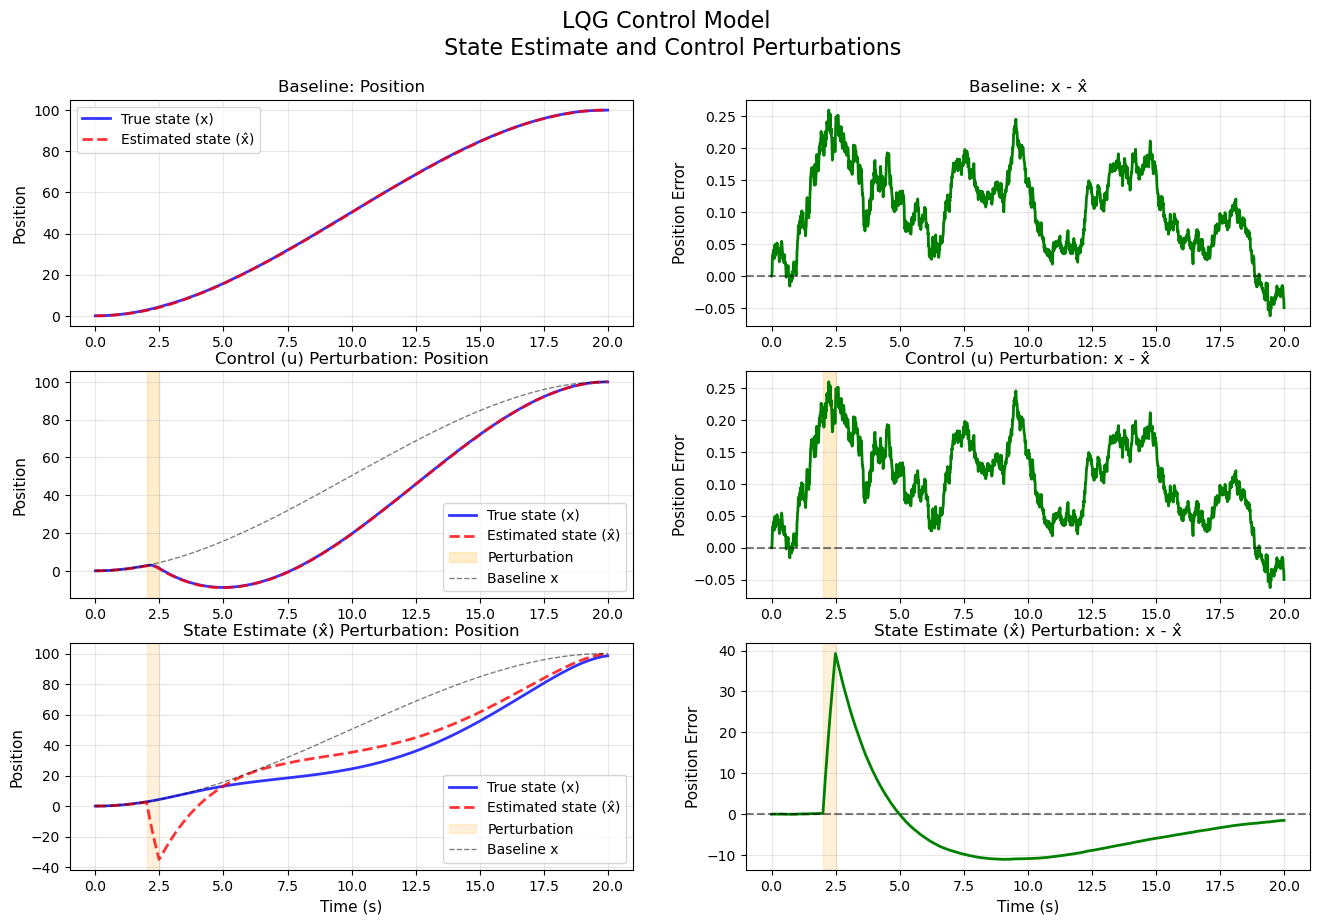

In [154]:
time = np.arange(horizon) * dt

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle('LQG Control Model \n State Estimate and Control Perturbations', fontsize=16, y=0.97)

# x axis labels
axes[2, 0].set_xlabel('Time (s)', fontsize=11)
axes[2, 1].set_xlabel('Time (s)', fontsize=11)

# row 1: Baseline
axes[0, 0].plot(time, x_baseline, 'b-', linewidth=2, label='True state (x)', alpha=0.8)
axes[0, 0].plot(time, xhat_baseline, 'r--', linewidth=2, label='Estimated state (x̂)', alpha=0.8)
axes[0, 0].set_ylabel('Position', fontsize=11)
axes[0, 0].set_title('Baseline: Position')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

error_baseline = x_baseline - xhat_baseline
axes[0, 1].plot(time, error_baseline, 'g-', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].set_ylabel('Position Error', fontsize=11)
axes[0, 1].set_title('Baseline: x - x̂')
axes[0, 1].grid(True, alpha=0.3)

# row 2: Control (u) Perturbation
axes[1, 0].plot(time, x_u_pert, 'b-', linewidth=2, label='True state (x)', alpha=0.8)
axes[1, 0].plot(time, xhat_u_pert, 'r--', linewidth=2, label='Estimated state (x̂)', alpha=0.8)
axes[1, 0].axvspan(perturbation_start*dt, perturbation_end*dt, alpha=0.2, color='orange', label='Perturbation')
# plot grey dashed baseline for reference
axes[1, 0].plot(time, x_baseline, 'k--', linewidth=1, alpha=0.5, label='Baseline x')
axes[1, 0].set_ylabel('Position', fontsize=11)
axes[1, 0].set_title('Control (u) Perturbation: Position')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

error_u_pert = x_u_pert - xhat_u_pert
axes[1, 1].plot(time, error_u_pert, 'g-', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 1].axvspan(perturbation_start*dt, perturbation_end*dt, alpha=0.2, color='orange')
axes[1, 1].set_ylabel('Position Error', fontsize=11)
axes[1, 1].set_title('Control (u) Perturbation: x - x̂')
axes[1, 1].grid(True, alpha=0.3)

# row 3: Direct xhat Perturbation
axes[2, 0].plot(time, x_xhat_direct, 'b-', linewidth=2, label='True state (x)', alpha=0.8)
axes[2, 0].plot(time, xhat_xhat_direct, 'r--', linewidth=2, label='Estimated state (x̂)', alpha=0.8)
axes[2, 0].axvspan(perturbation_start*dt, xhat_pulse_end*dt, color='orange', alpha=0.15, label='Perturbation')
# plot grey dashed baseline for reference
axes[2, 0].plot(time, x_baseline, 'k--', linewidth=1, alpha=0.5, label='Baseline x')
axes[2, 0].set_ylabel('Position', fontsize=11)
axes[2, 0].set_title('State Estimate (x̂) Perturbation: Position')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(time, error_xhat_direct, 'g-', linewidth=2)
axes[2, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[2, 1].axvspan(perturbation_start*dt, xhat_pulse_end*dt, color='orange', alpha=0.15)
axes[2, 1].set_ylabel('Position Error', fontsize=11)
axes[2, 1].set_title('State Estimate (x̂) Perturbation: x - x̂')
axes[2, 1].grid(True, alpha=0.3)

# normalize y-axis per row: each row gets its own scale so perturbation effects are clear within that row
_row_pos = [
    np.concatenate([x_baseline,   xhat_baseline]),
    np.concatenate([x_u_pert,     xhat_u_pert]),
    np.concatenate([x_xhat_direct, xhat_xhat_direct]),
]
_row_err = [
    error_baseline,
    error_u_pert,
    error_xhat_direct,
]
for row, (pos_data, err_data) in enumerate(zip(_row_pos, _row_err)):
    _p_pad = (pos_data.max() - pos_data.min()) * 0.05
    axes[row, 0].set_ylim(pos_data.min() - _p_pad, pos_data.max() + _p_pad)
    _e_pad = (err_data.max() - err_data.min()) * 0.05
    axes[row, 1].set_ylim(err_data.min() - _e_pad, err_data.max() + _e_pad)

In [155]:
# deviation of x from baseline x at the end of the perturbation window
x_dev_u    = x_u_pert[perturbation_end]      - x_baseline[perturbation_end]
x_dev_xhat = x_xhat_direct[perturbation_end] - x_baseline[perturbation_end]

print(f"x deviation from baseline at end of perturbation window (t={perturbation_end} steps = {perturbation_end*dt:.2f}s):")
print(f"  u perturbation:    {x_dev_u:.4f}")
print(f"  xhat perturbation: {x_dev_xhat:.4f}")
print(f"  difference:        {abs(x_dev_u) - abs(x_dev_xhat):.6f}")
print(f"  magnitudes equal:  {abs(abs(x_dev_u) - abs(x_dev_xhat)) < 0.01}")


x deviation from baseline at end of perturbation window (t=250 steps = 2.50s):
  u perturbation:    -2.9539
  xhat perturbation: 0.0204
  difference:        2.933490
  magnitudes equal:  False


In [156]:
# time step when x returns to within tol of baseline x for each perturbed system
tol = 1.0

deviation_u    = np.abs(x_u_pert    - x_baseline)
deviation_xhat = np.abs(x_xhat_direct - x_baseline)

rec_u_step    = next((t for t in range(perturbation_end, horizon) if deviation_u[t]    < tol), None)
rec_xhat_step = next((t for t in range(perturbation_end, horizon) if deviation_xhat[t] < tol), None)

print(f"recovery to baseline x (tol={tol}):")
if rec_u_step is not None:
    print(f"  u perturbation:    t={rec_u_step} ({rec_u_step*dt:.2f}s)  [{rec_u_step - perturbation_end} steps after perturbation end]")
else:
    print(f"  u perturbation:    did not recover within horizon")
if rec_xhat_step is not None:
    print(f"  xhat perturbation: t={rec_xhat_step} ({rec_xhat_step*dt:.2f}s)  [{rec_xhat_step - perturbation_end} steps after perturbation end]")
else:
    print(f"  xhat perturbation: did not recover within horizon")


recovery to baseline x (tol=1.0):
  u perturbation:    t=1877 (18.77s)  [1627 steps after perturbation end]
  xhat perturbation: t=250 (2.50s)  [0 steps after perturbation end]


## Percentage Deviation of True State (x) and State Estimate (x_hat)
- deviation is normalized by the target position (total displacement = 100 units) 
- +5% means the perturbed x is 5 units ahead of baseline; -10% means 10 units behind

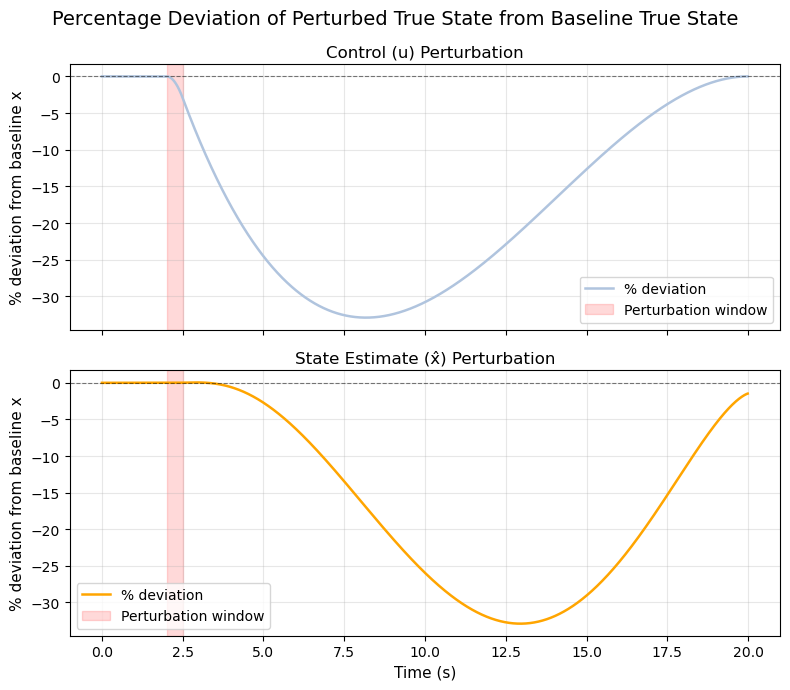

In [157]:
# percentage deviation of perturbed true state from baseline true state
# normalized by target position (total displacement) to avoid division by zero at t=0
pct_dev_u    = (x_u_pert    - x_baseline) / T_p * 100  # u perturbation
pct_dev_xhat = (x_xhat_direct - x_baseline) / T_p * 100  # xhat perturbation

# summary statistics per phase
phases = {
    'pre-perturbation':   slice(0, perturbation_start),
    'during perturbation': slice(perturbation_start, perturbation_end),
    'post-perturbation':  slice(perturbation_end, horizon),
}

# plot
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
fig.suptitle('Percentage Deviation of Perturbed True State from Baseline True State', fontsize=14)

for ax, pct_dev, label, color in zip(
    axes,
    [pct_dev_u, pct_dev_xhat],
    ['Control (u) Perturbation', 'State Estimate (x̂) Perturbation'],
    ['lightsteelblue', 'orange'],
):
    ax.plot(time, pct_dev, color=color, linewidth=1.8, label='% deviation')
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvspan(perturbation_start * dt, perturbation_end * dt,
               alpha=0.15, color='red', label='Perturbation window')
    ax.set_ylabel('% deviation from baseline x', fontsize=11)
    ax.set_title(label)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)', fontsize=11)
plt.tight_layout()
plt.show()

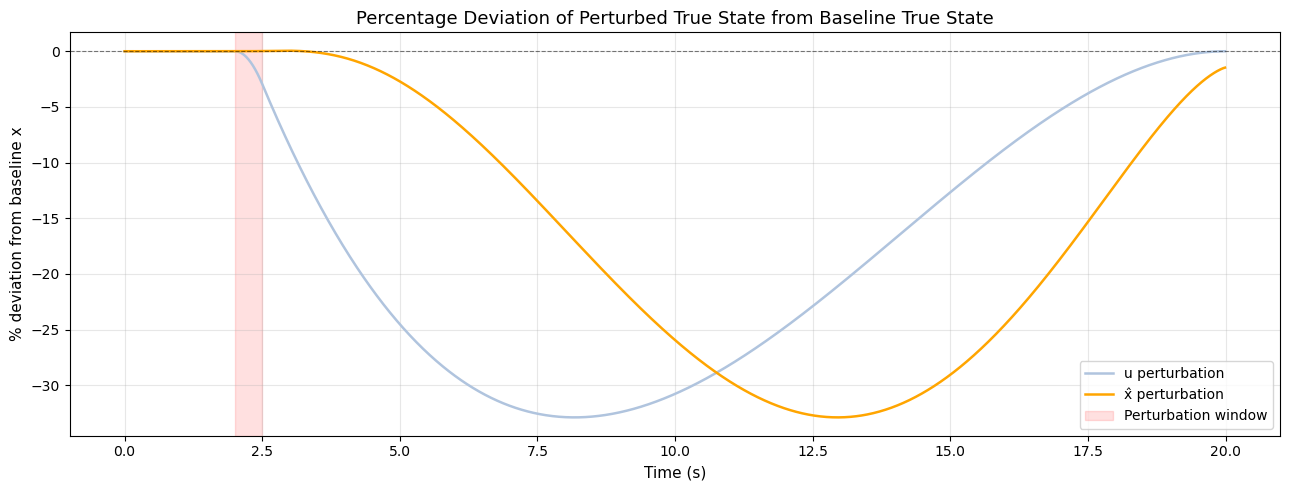

In [158]:
# overlay plot: both perturbations on the same axes for direct comparison
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(time, pct_dev_u,    color="lightsteelblue",  linewidth=1.8, label="u perturbation")
ax.plot(time, pct_dev_xhat, color="orange",  linewidth=1.8, label="x̂ perturbation")
ax.axhline(0, color="k", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvspan(perturbation_start * dt, perturbation_end * dt,
           alpha=0.12, color="red", label="Perturbation window")

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("% deviation from baseline x", fontsize=11)
ax.set_title("Percentage Deviation of Perturbed True State from Baseline True State", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [159]:
# percent error at perturbation window end in a table format
summary_df = pd.DataFrame({
    'Perturbation Type': ['Control (u)', 'State Estimate (x̂)'],
    '% Devation at Perturbation End': 
        [pct_dev_u[perturbation_end], pct_dev_xhat[perturbation_end]],
    'Mean % Deviation During Perturbation': [
        np.mean(np.abs(pct_dev_u[phases['during perturbation']])),
        np.mean(np.abs(pct_dev_xhat[phases['during perturbation']]))
    ],
    'Max % Deviation During Perturbation': [
        np.max(np.abs(pct_dev_u[phases['during perturbation']])),
        np.max(np.abs(pct_dev_xhat[phases['during perturbation']]))
    ],
    'Mean % Deviation After Perturbation': [
        np.mean(np.abs(pct_dev_u[phases['post-perturbation']])),
        np.mean(np.abs(pct_dev_xhat[phases['post-perturbation']]))
    ],
    'Max % Deviation After Perturbation': [
        np.max(np.abs(pct_dev_u[phases['post-perturbation']])),
        np.max(np.abs(pct_dev_xhat[phases['post-perturbation']]))
    ]
})

summary_df

,Perturbation Type,% Devation at Perturbation End,Mean % Deviation During Perturbation,Max % Deviation During Perturbation,Mean % Deviation After Perturbation,Max % Deviation After Perturbation
0,Control (u),-2.95389,0.954458,2.837899,18.741525,32.894517
1,State Estimate (x̂),0.02040,0.005438,0.019420,17.202336,32.894517


## recovery time by accuracy 
- thresholds: 50%, 30%, 5% deviation from baseline x (normalized by target position)

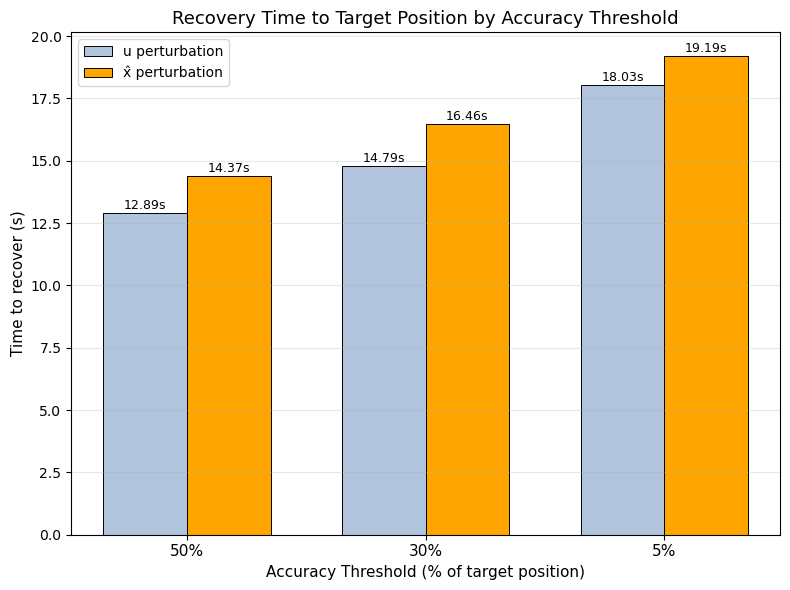

In [160]:
# distance from target position, as % of T_p
abs_pct_from_target_u    = np.abs(x_u_pert     - T_p) / T_p * 100
abs_pct_from_target_xhat = np.abs(x_xhat_direct - T_p) / T_p * 100

thresholds = [('50%', 50), ('30%', 30), ('5%', 5)]

def recovery_time(arr, thr, search_start, horizon):
    """First t >= peak deviation where arr[t] drops below thr."""
    peak_t = search_start + np.argmax(arr[search_start:horizon])
    rec_t  = next((t for t in range(peak_t, horizon) if arr[t] < thr), None)
    return rec_t

rec_u, rec_xhat = [], []
for _, thr in thresholds:
    t_u  = recovery_time(abs_pct_from_target_u,    thr, perturbation_end, horizon)
    t_xh = recovery_time(abs_pct_from_target_xhat, thr, perturbation_end, horizon)
    rec_u.append(time[t_u]   if t_u  is not None else np.nan)
    rec_xhat.append(time[t_xh] if t_xh is not None else np.nan)

thr_labels = [t[0] for t in thresholds]
x = np.arange(len(thr_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

bars_u    = ax.bar(x - width/2, rec_u,    width, label='u perturbation',  color='lightsteelblue', edgecolor='k', linewidth=0.7)
bars_xhat = ax.bar(x + width/2, rec_xhat, width, label='x̂ perturbation', color='orange', edgecolor='k', linewidth=0.7)

for bar in list(bars_u) + list(bars_xhat):
    h = bar.get_height()
    if not np.isnan(h):
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.2f}s',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(thr_labels, fontsize=11)
ax.set_xlabel('Accuracy Threshold (% of target position)', fontsize=11)
ax.set_ylabel('Time to recover (s)', fontsize=11)
ax.set_title('Recovery Time to Target Position by Accuracy Threshold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()